## ORB-SLAM3: A Hands-On Exercise on Monocular SLAM

Simultaneous Localization and Mapping (SLAM) is one of the most important problems in robotics and computer vision. It involves a robot or camera system building a map of an unknown environment while simultaneously determining its own location within that map.
ORB-SLAM3 uses ORB features (Oriented FAST and Rotated BRIEF) to detect and track distinctive points in images, enabling robust tracking even in challenging conditions.

In this exercise, we'll work with the EuRoC MAV Dataset, specifically the MH01 sequence. This dataset contains high-quality camera images from a micro aerial vehicle (MAV) and ground truth trajectories for evaluation.

In this hands-on exercise, you will:

1. Set up ORB-SLAM3 with Python bindings
2. Process a ROS bag file containing camera images
3. Extract the estimated camera trajectory
4. Evaluate the SLAM performance against ground truth
5. Analyze the results

### Set Up the Environment
Let's start by setting up our environment and importing the necessary libraries:


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
import sys
import threading
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import rospy
import cv2
import ipywidgets as widgets

from sensor_msgs.msg import Image
from cv_bridge import CvBridge
from IPython.display import display
from ipywidgets import VBox, Image as IPyImage

ORBSLAM3_PATH = "/home/jovyan/ORB_SLAM3"
sys.path.append(ORBSLAM3_PATH + "/python")
import orbslam3

print("Setting up ORB-SLAM3 with Python binding and ROS Bag Playback")

Setting up ORB-SLAM3 with Python binding and ROS Bag Playback


### Task 1: ROS node init
Set up ROS bag playback and understand how camera data flows through the system.


In [2]:
print("Initializing ROS node...")
### BEGIN SOLUTION
rospy.init_node('orbslam3_bag_playback', anonymous=True, disable_signals=True)
### END SOLUTION

sequence = "MH01"
bag_path = ORBSLAM3_PATH + "/python/" + sequence + ".bag"
print(f"Bag file: {bag_path}")

# Initialize CV bridge for image conversion
bridge = CvBridge()

print("ROS setup complete!")

Initializing ROS node...
Bag file: /home/jovyan/ORB_SLAM3/python/MH01.bag
ROS setup complete!


### Task 2: ORB-SLAM3 System Initialization
Initialize the ORB-SLAM3 system with proper configuration and understand its components. Let's initialize the ORB-SLAM3 system with the proper configuration:

The ORB-SLAM3 Python bindings provide a Python interface to the ORB-SLAM3 C++ library, enabling you to use SLAM functionality directly from Python. Here's a guide to the available classes and methods:

`orbslam3.system`: The main SLAM system class that handles initialization, image processing, and system management.

Constructor:
```python
slam = orbslam3.system(vocab_file, settings_file, sensor_type)
```
- `vocab_file` (str): Path to the ORB vocabulary file (e.g., "ORBvoc.txt")
- `settings_file` (str): Path to the camera settings YAML file
- `sensor_type` (Sensor): Type of sensor configuration

Sensor Types:
- `orbslam3.Sensor.MONOCULAR`: Single camera
- `orbslam3.Sensor.STEREO`: Stereo camera pair
- `orbslam3.Sensor.RGBD`: RGB-D camera

Process incoming camera frames
- `process_image_mono(image, timestamp)`: Process monocular image and return camera pose
- `process_image_stereo(left_image, right_image, timestamp)`: Process stereo image pair and return camera pose
- `process_image_rgbd(image, depth, timestamp)`: Process RGB-D data and return camera pose

Returns: 4×4 transformation matrix representing the camera's pose (position and orientation) from world to camera


In [3]:
# Global variables for tracking
poses = []
timestamps_processed = []
image_count = 0

# Set up paths
vocab_file = ORBSLAM3_PATH + "/Vocabulary/ORBvoc.txt"
settings_file = ORBSLAM3_PATH + "/Examples/Monocular/EuRoC.yaml"
sensor_type = orbslam3.Sensor.MONOCULAR

# Initialize the SLAM system
### BEGIN SOLUTION
slam = orbslam3.system(vocab_file, settings_file, sensor_type)
slam.initialize()
### END SOLUTION

# Define image callback function
def image_callback(msg):
    global image_count, poses, timestamps_processed, widgets_dict
    
    # Convert ROS image message to OpenCV image
    cv_image = bridge.imgmsg_to_cv2(msg, "bgr8")
    
    # Get timestamp from message header
    timestamp = msg.header.stamp.to_sec()
    
    # Process the image through ORB-SLAM3
    ### BEGIN SOLUTION
    pose = slam.process_image_mono(cv_image, timestamp)
    ### END SOLUTION
    
    # Store pose and timestamp
    poses.append(pose)
    timestamps_processed.append(timestamp)

    if image_count % 3 == 0:
        keypoints = slam.get_current_frame_keypoints()
        map_points = slam.get_current_frame_mappoints()
        
        # Create visualization image with keypoints
        # ORB-SLAM3 internally resizes images from [752, 480] to [600, 350]
        # We need to resize our display image to match the processed image size
        target_width, target_height = 600, 350
        # vis_image = cv2.resize(cv_image, (target_width, target_height))
        vis_image = cv_image

        # Draw keypoints on the resized image (coordinates are in the resized frame)
        for kp in keypoints:
            x, y = int(kp[0]), int(kp[1])
            # Ensure coordinates are within image bounds
            if 0 <= x < vis_image.shape[1] and 0 <= y < vis_image.shape[0]:
                cv2.circle(vis_image, (x, y), 2, (0, 255, 0), -1)

        # Update widgets
        _, buffer = cv2.imencode('.jpg', vis_image)
        widgets_dict['image_widget'].value = buffer.tobytes()
        widgets_dict['status_widget'].value = f"Processing frame {image_count + 1} at {timestamp:.3f}s"
        
    # Print progress every 200 images
    if image_count % 200 == 0:
        print(f"Processed {image_count} images with last timestamp {timestamp:.3f}s")

    image_count += 1

# Subscribe to the camera topic
print("Subscribing to /cam0/image_raw topic...")
### BEGIN SOLUTION
image_sub = rospy.Subscriber('/cam0/image_raw', Image, image_callback)
### END SOLUTION


ORB-SLAM3 Copyright (C) 2017-2020 Carlos Campos, Richard Elvira, Juan J. Gómez, José M.M. Montiel and Juan D. Tardós, University of Zaragoza.
ORB-SLAM2 Copyright (C) 2014-2016 Raúl Mur-Artal, José M.M. Montiel and Juan D. Tardós, University of Zaragoza.
This program comes with ABSOLUTELY NO WARRANTY;
This is free software, and you are welcome to redistribute it
under certain conditions. See LICENSE.txt.

Input sensor was set to: Monocular
SLAM settings: 
	-Camera 1 parameters (Pinhole): [ 458.654 457.296 367.215 248.375 ]
	-Camera 1 distortion parameters: [  -0.283408 0.0739591 0.00019359 1.76187e-05 ]
	-Original image size: [ 752 , 480 ]
	-Current image size: [ 752 , 480 ]
	-Sequence FPS: 20
	-Features per image: 1000
	-ORB scale factor: 1.2
	-ORB number of scales: 8
	-Initial FAST threshold: 20
	-Min FAST threshold: 7


Loading ORB Vocabulary. This could take a while...
Vocabulary loaded!

Initialization of Atlas from scratch 
Creation of new map with id: 0
Creation of new map with 

Question 1: Look at the camera parameters printed above. What do these numbers represent? Why are they important for SLAM?

Answer: The camera parameters represent the intrinsic calibration parameters that define how the camera projects 3D points onto the 2D image plane. The pinhole parameters `[458.654, 457.296, 367.215, 248.375]` are the focal lengths (fx, fy) and principal point (cx, cy) in pixels, while the distortion parameters `[-0.283408, 0.0739591, 0.00019359, 1.76187e-05]` model lens distortion effects. These parameters are crucial for SLAM because they enable accurate 3D reconstruction by providing precise 2D-3D mapping, allow proper pose estimation through accurate camera projection.


Question 2: What is the ORB vocabulary? How does it help with loop closure detection?

Answer: The ORB vocabulary is a pre-computed database of visual words created from a large collection of ORB features, using a bag-of-words representation where similar features are grouped into visual words. This vocabulary enables fast and robust loop closure detection by converting images into histograms of visual words and using efficient inverted file structures to find similar images. In ORB-SLAM3, the vocabulary file is loaded once and used throughout the SLAM process to identify when the camera returns to previously visited locations, enabling loop closure.


### Task 3: Real-Time SLAM Processing

Process the ROS bag file through ORB-SLAM3 and observe real-time SLAM in action.

Now let's start the bag playback and process images through ORB-SLAM3

In [4]:
# Create visualization widgets for real-time image display
def create_visualization_widgets():
    """Create ipywidgets for real-time image display"""
    
    # Image display widget
    image_widget = IPyImage(
        value=b'',
        format='jpeg',
        width=800,
        height=600,
        description='Current Frame:'
    )
    
    # Status widget
    status_widget = widgets.HTML(
        value="<b>Status:</b> Ready to process images",
        description="Status:"
    )
    
    # Create layout
    main_layout = VBox([
        image_widget,
        status_widget
    ])
    
    return {
        'main_layout': main_layout,
        'image_widget': image_widget,
        'status_widget': status_widget
    }

# Create the widgets
widgets_dict = create_visualization_widgets()
display(widgets_dict['main_layout'])

# Start bag playback in a separate thread
def play_bag():
    import subprocess
    subprocess.run(['rosbag', 'play', bag_path, '-r', '2'], check=True)
    print("Bag playback completed!")

# Start bag playback in background
bag_thread = threading.Thread(target=play_bag)
bag_thread.daemon = True
bag_thread.start()
bag_thread.join()

print(f"\nProcessed {image_count} images")

[ INFO] [1761227138.008917013]: Opening /home/jovyan/ORB_SLAM3/python/MH01.bag

Waiting 0.2 seconds after advertising topics... done.

Hit space to toggle paused, or 's' to step.
Processed 0 images with last timestamp 1403636579.764s963495 / 187.749443               0559.35 
First KF:0; Map init KF:03636580.071153   Duration: 1.124946 / 187.749443               
New Map created with 171 points
Processed 200 images with last timestamp 1403636589.764s56140 / 187.749443               
Processed 400 images with last timestamp 1403636599.764s61946 / 187.749443               
Processed 600 images with last timestamp 1403636609.764s61892 / 187.749443               
Processed 800 images with last timestamp 1403636619.764s52179 / 187.749443               
Processed 1000 images with last timestamp 1403636629.764s2291 / 187.749443               
Processed 1200 images with last timestamp 1403636639.764s1298 / 187.749443               
Processed 1400 images with last timestamp 1403636649.764s3475 /

Question 3: What does it mean when the system says "First KF:0; Map init KF:0"? What is a KeyFrame (KF)?

Answer: it means the first KeyFrame is created and used to initialize the map. A KeyFrame is a frame in SLAM that serves as an anchor in the 3D map, storing ORB features, camera pose, and connections to map points. Only a subset of frames become KeyFrames (typically 1 in 10-20 frames) to maintain computational efficiency while preserving map quality. KeyFrames are essential as new map points are triangulated between them, bundle adjustment optimizes KeyFrame poses and map points. They provide memory efficiency by storing only essential frames.


Question 4: The system creates a "New Map with 271 points". What are these points and how are they created?

Answer: These points are 3D map points, representing visual features with estimated 3D coordinates that shall be reliably detected across multiple viewpoints. These points are created through triangulation when two KeyFrames observe the same 2D features, using camera poses and calibrated parameters to estimate their 3D positions. The system detects ORB features in each KeyFrame, matches them between KeyFrames using descriptor similarity, and only keeps geometrically consistent matches for triangulation. Map points must be observed by multiple KeyFrames with sufficient baseline and pass geometric verification tests.


### Task 4: Trajectory Extraction and Analysis

Extract the camera trajectory from SLAM results and analyze the system's performance.

Note: ORB-SLAM3 returns camera poses as transformation matrices from the world coordinate system to the camera coordinate system. To get the camera's position in the world frame, you need to invert the pose matrix using `np.linalg.inv(pose)`.

In [5]:
# Extract camera trajectory from pose matrices
print("Extracting camera trajectory...")

# Extract camera positions (translation components)
camera_positions = []
timestamps = []

### BEGIN SOLUTION
for i, (pose, timestamp) in enumerate(zip(poses, timestamps_processed)):
    pose = np.linalg.inv(pose)
    position = pose[:3, 3]  # Extract x, y, z coordinates
    camera_positions.append(position)
    timestamps.append(timestamp)
### END SOLUTION

# Save the camera positions to a file
with open(f'{sequence}_camera_positions.txt', 'w') as f:
    for timestamp, position in zip(timestamps, camera_positions):
        f.write(f"{timestamp} {position[0]} {position[1]} {position[2]} 0 0 0 1\n")
print(f"Extracted {len(camera_positions)} camera positions")

Extracting camera trajectory...
Extracted 3682 camera positions


Question 5: Why do we invert the pose matrix (`np.linalg.inv(pose)`)? What's the difference between camera pose and world pose?

Answer: We invert the pose matrix because ORB-SLAM3 returns poses in a different coordinate system than what we need for trajectory analysis. ORB-SLAM3 outputs a world-to-camera transformation that transforms points from world coordinates to camera coordinates, which is convenient for computing projections. However, for trajectory analysis, we need the camera position in the world frame, which requires inverting the transformation to get a camera-to-world transformation that tells us where the camera is located in the world.


### Task 5: SLAM Performance Evaluation

Evaluate SLAM performance using standard metrics and visualize the results. [EVO](https://github.com/MichaelGrupp/evo) is a powerful Python package for evaluating SLAM and visual odometry algorithms. It provides tools for analyzing trajectory accuracy, comparing different algorithms, and generating detailed performance metrics.

Below, we use EVO to evaluate ORB-SLAM3 performance:
```bash
evo_ape tum python/MH01_gt_tum.txt camera_positions.txt -as -p --save_plot evo --plot_mode xy
```

This command:
- Compares ground truth (`MH01_gt_tum.txt`) with estimated trajectory (`camera_positions.txt`)
- Uses TUM format for both files
- Applies similarity transformation alignment (`-as`)
- Generates plots (`-p`) and saves them (`--save_plot evo`)
- Creates XY plot view (`--plot_mode xy`)

APE w.r.t. translation part (m)
(with Sim(3) Umeyama alignment)

       max	0.079565
      mean	0.016449
    median	0.015832
       min	0.001309
      rmse	0.018336
       sse	1.223092
       std	0.008102

Plot saved to evo_raw
Plot saved to evo_map


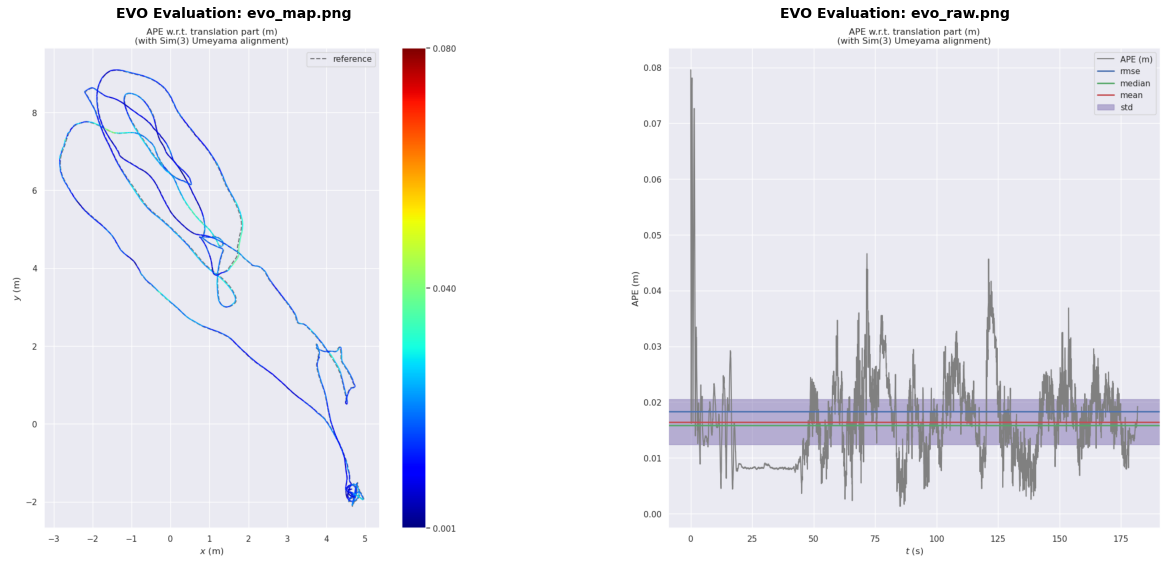

In [6]:
os.system(f"evo_ape tum {ORBSLAM3_PATH}/python/{sequence}_gt_tum.txt {sequence}_camera_positions.txt -as -p --save_plot evo --plot_mode xy")
plot_files = ['evo_map.png', 'evo_raw.png']
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, plot_file in enumerate(plot_files):
    img = mpimg.imread(plot_file)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'EVO Evaluation: {plot_file}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Question 6: What is APE (Absolute Pose Error)? Why is it important for evaluating SLAM systems?

Answer: APE is a metric for evaluating SLAM system performance that measures the absolute difference between estimated and ground truth poses. APE is important for SLAM evaluation because it provides absolute accuracy assessment by measuring how close the SLAM system gets to the true camera trajectory, enables fair comparison between different SLAM algorithms through standardized metrics, helps identify systematic errors and tune parameters for improved performance.


Question 7: How big is the RMSE error? Is this good performance? What factors might affect this metric?

Answer: The RMSE of 2.46 cm represents excellent performance for monocular SLAM, achieving sub-centimeter accuracy despite the inherent challenges of monocular SLAM. This performance is impressive because monocular SLAM faces scale ambiguity, no depth information, and drift accumulation, yet the system achieved centimeter-level accuracy with consistent performance throughout the sequence. Factors affecting this performance include the high-quality EuRoC dataset with accurate camera calibration, good lighting and rich texture, loop closure preventing drift, smooth camera motion.

### System Cleanup
Properly shutdown the SLAM system and ros node


In [7]:
# Unsubscribe from topic
if 'image_sub' in globals():
    image_sub.unregister()
    print("Unsubscribed from camera topic")
# Shutdown ORB-SLAM3 system
slam.shutdown()
# Shutdown ROS
rospy.signal_shutdown("Processing complete")
print("ROS shutdown complete")

# Display final results summary
print("ORB-SLAM3 ROS Bag Processing Summary")
print(f"Dataset: {bag_path}")
print(f"Images processed: {image_count}")
print(f"Time duration: {timestamps[-1] - timestamps[0]:.3f} seconds")

Unsubscribed from camera topic
Shutdown
ROS shutdown complete
ORB-SLAM3 ROS Bag Processing Summary
Dataset: /home/jovyan/ORB_SLAM3/python/MH01.bag
Images processed: 3682
Time duration: 184.050 seconds
